In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df = pd.read_pickle("../data/skin-lesion-data/binary.pickle")
df_numerical = pd.read_pickle("../data/skin-lesion-data/numerical.pickle")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773 entries, 1 to 2289
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   patient_id           773 non-null    string  
 1   lesion_id            773 non-null    int64   
 2   smoke                773 non-null    boolean 
 3   drink                773 non-null    boolean 
 4   background_father    773 non-null    category
 5   background_mother    773 non-null    category
 6   age                  773 non-null    int64   
 7   pesticide            773 non-null    boolean 
 8   gender               773 non-null    category
 9   skin_cancer_history  773 non-null    boolean 
 10  cancer_history       773 non-null    boolean 
 11  has_piped_water      773 non-null    boolean 
 12  has_sewage_system    773 non-null    boolean 
 13  fitspatrick          773 non-null    float64 
 14  region               773 non-null    category
 15  diameter_1           773 no

In [4]:
df_numerical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 773 entries, 1 to 2289
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   smoke                          773 non-null    int64  
 1   drink                          773 non-null    int64  
 2   age                            773 non-null    float64
 3   pesticide                      773 non-null    int64  
 4   gender                         773 non-null    int64  
 5   skin_cancer_history            773 non-null    int64  
 6   cancer_history                 773 non-null    int64  
 7   has_piped_water                773 non-null    int64  
 8   has_sewage_system              773 non-null    int64  
 9   fitspatrick                    773 non-null    float64
 10  diameter_1                     773 non-null    float64
 11  diameter_2                     773 non-null    float64
 12  itch                           773 non-null    int64  

In [5]:
X = df.drop(columns="malignant")
y = df["malignant"]
X_numerical = df_numerical.drop(columns="malignant")
y_numerical = df_numerical["malignant"]

# Extra
y_labeled = y.map({False: "Non-Malignant", True: "Malignant"})

# Data visualization

In [6]:
default_plotly_colors = px.colors.qualitative.Plotly

# PCA

All the code used to produce the graphs below has been extracted from the Plotly Documentation [(PCA Visualization in Python)](https://plotly.com/python/pca-visualization/).

In [7]:
from sklearn.decomposition import PCA

In [8]:
pca = PCA()
pca.fit(X_numerical)
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "# Components", "y": "Explained Variance"}
)

## 2D

In [9]:
pca_2d = PCA(n_components=2)
components_2d = pca_2d.fit_transform(X_numerical)

pca_2d.explained_variance_ratio_

array([0.13014793, 0.09221091])

In [10]:
fig = px.scatter(
    components_2d,
    x=0,
    y=1,
    color=y_labeled,
    labels={"color": "Diagnostic"},
    color_discrete_map={
        "Non-Malignant": default_plotly_colors[0],
        "Malignant": default_plotly_colors[1]
    }
)

fig.show()


## 3D

In [11]:
pca_3d = PCA(n_components=3)
components_3d = pca_3d.fit_transform(X_numerical)

pca_3d.explained_variance_ratio_

array([0.13014793, 0.09221091, 0.07435163])

In [12]:
fig = px.scatter_3d(
    components_3d,
    x=0,
    y=1,
    z=2,
    color=y_labeled,
    labels={"color": "Diagnostic"},
    color_discrete_map={
        "Non-Malignant": default_plotly_colors[0],
        "Malignant": default_plotly_colors[1]
    }
)
fig.show()

# Correlation

In [13]:
spearman_matrix = df_numerical.corr(method="spearman")
pearson_matrix = df_numerical.corr(method="pearson")

In [14]:
spearman_matrix["malignant"].sort_values(ascending=False)

malignant                        1.000000
biopsed                          0.554450
grew                             0.424969
bleed                            0.384195
elevation                        0.368504
hurt                             0.270532
region_FACE                      0.163484
region_NOSE                      0.159659
changed                          0.156000
diameter_1                       0.132769
diameter_2                       0.115439
smoke                            0.097441
itch                             0.089164
region_EAR                       0.082711
region_CHEST                     0.079047
background_father_BRAZIL         0.066031
region_BACK                      0.054654
background_father_GERMANY        0.052122
background_mother_NORWAY         0.047304
background_mother_POLAND         0.047304
pesticide                        0.045718
drink                            0.043098
region_NECK                      0.040397
background_mother_GERMANY        0

In [15]:
pearson_matrix["malignant"].sort_values(ascending=False)

malignant                        1.000000
biopsed                          0.554450
grew                             0.424969
bleed                            0.384195
elevation                        0.368504
hurt                             0.270532
region_FACE                      0.163484
region_NOSE                      0.159659
changed                          0.156000
smoke                            0.097441
diameter_1                       0.090208
itch                             0.089164
diameter_2                       0.084321
region_EAR                       0.082711
region_CHEST                     0.079047
background_father_BRAZIL         0.066031
region_BACK                      0.054654
background_father_GERMANY        0.052122
background_mother_POLAND         0.047304
background_mother_NORWAY         0.047304
pesticide                        0.045718
age                              0.044820
drink                            0.043098
region_NECK                      0

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

features = ["age", "diameter_1", "diameter_2"]
fig = make_subplots(rows=1, cols=3, subplot_titles=features, y_title="Diagnostic")

malignant = df_numerical["malignant"] == 1
non_malignant = df_numerical["malignant"] == 0

for i, attr in enumerate(features, start=1):
    fig.add_trace(
        go.Scatter(
            x=df.loc[non_malignant, attr],
            y=df_numerical.loc[non_malignant, "malignant"],
            mode="markers",
            name="Non-Malignant",
            marker=dict(size=8, color=default_plotly_colors[0], opacity=0.1),
            showlegend=False,
        ),
        row=1, col=i,
    )

    fig.add_trace(
        go.Scatter(
            x=df.loc[malignant, attr],
            y=df_numerical.loc[malignant, "malignant"],
            mode="markers",
            name="Malignant",
            marker=dict(size=8, color=default_plotly_colors[1], opacity=0.1),
            showlegend=False,
        ),
        row=1, col=i,
    )

# The code below creates a custom legend.
# The approach was adapted from: https://community.plotly.com/t/adding-custom-legend-in-plotly/65610/3
fig.add_trace(go.Scatter(
    x=[None],
    y=df_numerical["malignant"],
    mode="markers",
    name="Malignant",
    marker=dict(size=7, color=default_plotly_colors[1], symbol="circle"),
))

fig.add_trace(go.Scatter(
    x=[None],
    y=df_numerical["malignant"],
    mode="markers",
    name="Non-Malignant",
    marker=dict(size=7, color=default_plotly_colors[0], symbol="circle"),
))

fig.update_layout(title_text="Continous Features by Prediction", showlegend=True)
fig.show()


In [17]:
import plotly.express as px



fig = px.violin(
    df,
    x="age",
    y=y_labeled,
    color=y_labeled,
    box=True,
    points="all",
    labels={"y": "Diagnostic", "color": "Diagnostic"},
    title="Distribution of Age by Diagnostic",
    height=700,
    color_discrete_map={
        "Non-Malignant": default_plotly_colors[0],
        "Malignant": default_plotly_colors[1]
    }
)

fig.show()


In [18]:
import math

boolean_features = [
    "biopsed", "grew", "bleed", "elevation", "hurt", "changed", "smoke",
    "itch", "has_sewage_system", "has_piped_water", "pesticide", "drink",
    "gender", "skin_cancer_history", "cancer_history"
]

long_df = (
    df_numerical.melt(id_vars="malignant", value_vars=boolean_features,
            var_name="feature", value_name="value")
    .replace({"malignant": {1: "Malignant", 0: "Non-Malignant"}})
    .replace({"value": {1: "True", 0: "False"}})
)

rows = math.ceil(len(boolean_features) / 4)

fig = px.histogram(
    long_df,
    x="value",
    color="malignant",
    facet_col="feature",
    facet_col_wrap=4,
    facet_row_spacing=0.05,
    barmode="group",
    category_orders={"malignant": ["Non-Malignant", "Malignant"]},
    labels={"malignant": "Diagnostic"},
    title="Boolean Features by Diagnostic",
    height=300 * rows
)

fig.update_xaxes(showticklabels=True, title_text=None)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # clean facet titles

fig.show()


In [19]:
def plot_categorical_data(feature: str, title: str):
    value_list = []
    malignant_list = []
    count_list = []

    for col in df[feature].unique():
        col_values = (df[feature] == col)

        count_malignant = ((col_values == 1) & (df["malignant"] == 1)).sum()
        count_non_malignant = ((col_values == 1) & (df["malignant"] == 0)).sum()

        value_list.append(col)
        malignant_list.append("Malignant")
        count_list.append(count_malignant)

        value_list.append(col)
        malignant_list.append("Non-Malignant")
        count_list.append(count_non_malignant)

    agg_df = pd.DataFrame({
        feature: value_list,
        "malignant": malignant_list,
        "count": count_list
    })

    fig = px.bar(
        agg_df,
        x=feature,
        y="count",
        color="malignant",
        barmode="group",
        text="count",
        labels={"malignant": "Diagnostic"},
        title=title,
        color_discrete_map={
        "Non-Malignant": default_plotly_colors[0],
        "Malignant": default_plotly_colors[1]
        }
    )

    fig.show()

In [20]:
plot_categorical_data("region", "Region By Diagnostic")

In [21]:
plot_categorical_data("background_father", "Background Father By Diagnostic")

In [22]:
plot_categorical_data("background_mother", "Background Mother By Diagnostic")

The anatomical-region distribution reveals strong spatial patterns in lesion malignancy within the PAD-UFES-20 dataset. Malignant lesions appear disproportionately on the face, chest, back, nose, and forearm, with the face showing the highest malignant frequency, consistent with clinical evidence that chronically sun-exposed sites have elevated skin-cancer risk. In contrast, non-malignant lesions are more common on the forearm, hand, thigh, and arm, suggesting these locations may contain more benign dermatological conditions such as nevi or inflammatory lesions. The extreme imbalance in some regions—for example, the face and nose dominated by malignant cases—highlights anatomical location as a strong predictive feature and supports the value of including clinical metadata alongside images. Conversely, areas like the abdomen, scalp, and lip show very low counts overall, indicating limited statistical reliability for those regions. Overall, this distribution reinforces that lesion location carries substantial diagnostic value and should be considered during modelling, particularly in multimodal or tabular-feature-based classifiers.

## Attribute combination

In [23]:
fig = px.scatter(
    df,
    x="diameter_1",
    y="diameter_2",
    color=y_labeled,
    labels={"color": "Diagnostic"},
    color_discrete_map={
        "Non-Malignant": default_plotly_colors[0],
        "Malignant": default_plotly_colors[1]
    }
)
fig.show()

In [24]:
agg_df = df.groupby(["grew", "bleed", "malignant"], observed=True).size().reset_index(name="count")

agg_df["grew & bleed"] = (
    agg_df["grew"].astype(str) +
    " & " +
    agg_df["bleed"].astype(str)
)

agg_df["malignant"] = agg_df["malignant"].map({False: "Non-Malignant", True: "Malignant"})

fig = px.bar(
    agg_df,
    x="grew & bleed",
    y="count",
    color=agg_df["malignant"],
    barmode="group",
    text="count",
    labels={"malignant": "Diagnostic"}
)

fig.show()

## Unprocessed dataset

In [25]:
unprocessed_df = pd.read_pickle("../data/skin-lesion-data/default.pickle")


In [26]:
unprocessed_df["has_sewage_system"] = unprocessed_df["has_sewage_system"].astype("string")
unprocessed_df["has_sewage_system"] = unprocessed_df["has_sewage_system"].fillna("None")
unprocessed_df["has_sewage_system"]

0        None
1        True
2        None
3        None
4       False
        ...  
2293     None
2294     True
2295     None
2296    False
2297     None
Name: has_sewage_system, Length: 2298, dtype: string

In [27]:
agg_df = unprocessed_df.groupby(["has_sewage_system", "diagnostic"], observed=True).size().reset_index(name="count")

fig = px.bar(
    agg_df,
    x="has_sewage_system",
    y="count",
    color="diagnostic",
    barmode="group",
    title="Distribution of Diagnostic Categories by (grew, bleed) Combination",
    text="count"
)

fig.show()

# Clustering

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0).fit(X_numerical)

In [29]:
comparison_df = pd.DataFrame({"malignant": y_numerical, "cluster": kmeans.labels_})


In [30]:
non_malignant = (comparison_df.loc[(comparison_df["malignant"] == 0)])
malignant = (comparison_df.loc[(comparison_df["malignant"] == 1)])


non_malignant_counts = non_malignant["cluster"].value_counts()
malignant_counts = malignant["cluster"].value_counts()

non_malignant_counts, malignant_counts

(cluster
 0    169
 1    113
 Name: count, dtype: int64,
 cluster
 0    319
 1    172
 Name: count, dtype: int64)

In [31]:
clustering_df = pd.DataFrame({
    "cluster": [0, 1],
    "Non-Malignant": non_malignant_counts.values,
    "Malignant": malignant_counts.values
})

clustering_df_melted = clustering_df.melt(
    id_vars="cluster",
    value_vars=["Non-Malignant", "Malignant"],
    var_name="Diagnostic",
    value_name="count"
)


fig = px.bar(
    clustering_df_melted,
    x="cluster",
    y="count",
    color="Diagnostic",
    barmode="group"
)
fig.show()

## Clustering with PCA (2D)

In [32]:
kmeans_2d = KMeans(n_clusters=2).fit(components_2d)

In [33]:
import pandas as pd
import plotly.express as px

df_clustering = pd.DataFrame(components_2d, columns=["x", "y"])
df_clustering["Diagnostic"] = y.map({True: "Malignant", False: "Non-malignant"})
df_clustering["Cluster"] = kmeans_2d.labels_.astype(str) # `.astype(str)` prevents plotly from showing a color bar

symbol_map = {
    "Malignant": "x",
    "Non-malignant": "circle"
}

fig = px.scatter(
    df_clustering,
    x="x",
    y="y",
    color="Cluster",
    symbol="Diagnostic",
    symbol_map=symbol_map,
    color_discrete_sequence=px.colors.qualitative.Bold,
)
# Making symbols bigger and adding a surrounding line for better visibility
fig.update_traces(marker=dict(size=10, line=dict(width=1, color="black")))

fig.update_layout(
    title="KMeans Clustering vs Diagnostic (Malignant / Non-malignant)",
    legend_title_text="Cluster / Diagnosric",
)

fig.show()


In [34]:
labeled_y = y.replace(to_replace=[0, 1], value=["Malignant", "Non-Malignant"])

# Target distribution (class imbalance)

In [35]:
fig = px.pie(
    names=labeled_y.value_counts().index,
    values=labeled_y.value_counts().values,
    title="Malignant vs Benign Lesions",
    color_discrete_sequence=["#66c2a5", "#fc8d62"]
)
fig.update_traces(textinfo='percent+label')
fig.show()

The class distribution plot shows a substantial imbalance in the PAD-UFES-20 dataset, with malignant lesions representing 63.5% of all samples and benign lesions accounting for only 36.5%. This imbalance has important implications for model performance: classifiers may naturally gravitate toward predicting the majority class, inflating accuracy while masking poor performance on minority (benign) cases. It also explains why the Zero-R baseline achieves over 60% accuracy simply by predicting the majority class. In a clinical context, such imbalance is crucial because both classes carry significant diagnostic importance—overpredicting malignancy can increase unnecessary biopsies and patient anxiety, while underpredicting it risks missed diagnoses. Therefore, evaluation metrics such as sensitivity, specificity, precision, F1-score, and AUC become essential for a fair assessment. This distribution further justifies applying balanced evaluation strategies and potentially using resampling or class-weight adjustments in later modelling stages to prevent biased learning.

**Correlation heat-map (numeric + one-hot features)**

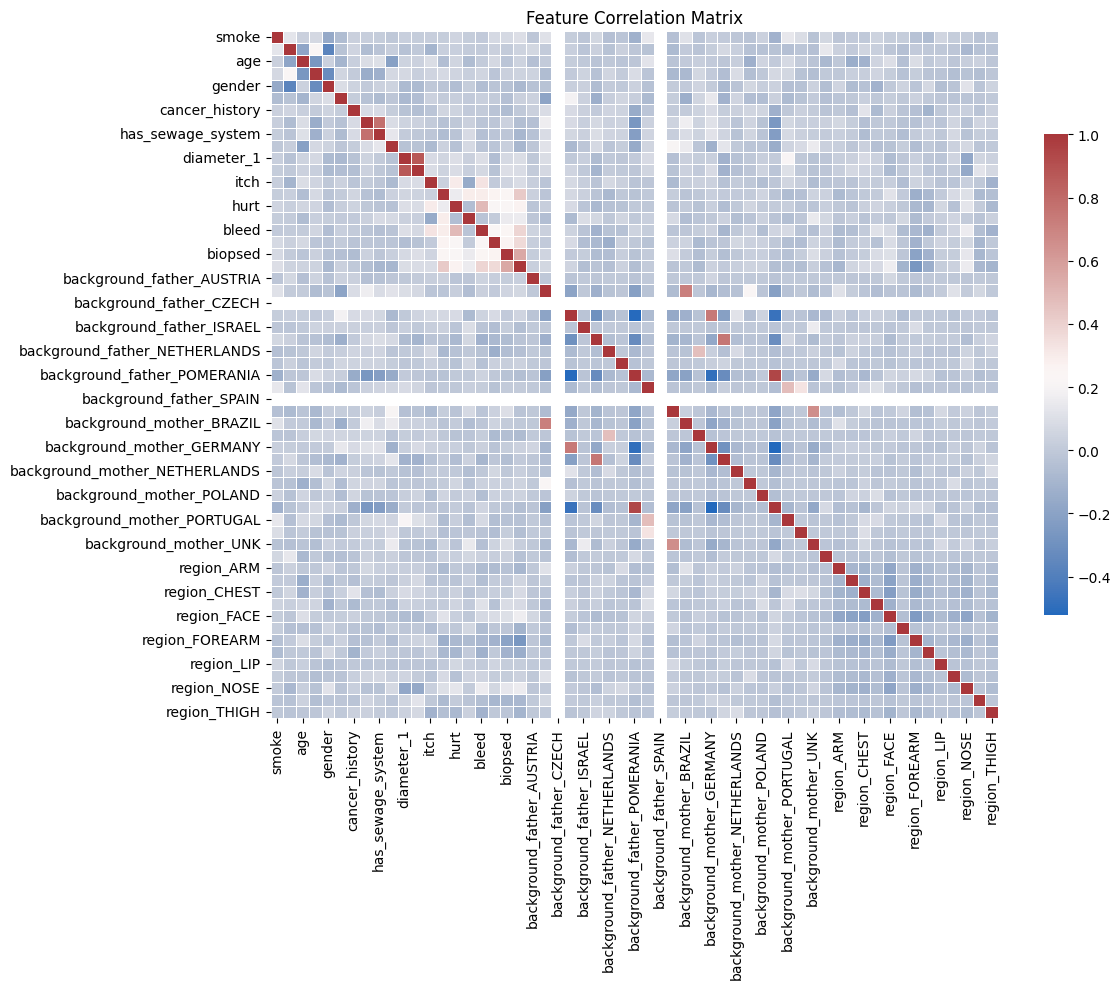

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only columns that are numeric (float/int)
corr = df_numerical.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="vlag", annot=False, linewidths=.5, cbar_kws={"shrink": .7})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Age vs Lesion Size (diameter_1) coloured by malignancy

In [38]:
fig = px.scatter(
    df, x="age", y="diameter_1",
    color=labeled_y, size="diameter_2",
    hover_data=["fitspatrick", "itch", "bleed"],
    title="Age vs Primary Diameter (size = secondary diameter)",
    labels={"age":"Age (scaled)", "diameter_1":"Diameter 1 (scaled)"},
    color_discrete_map={"Benign":"#66c2a5", "Malignant":"#fc8d62"}
)
fig.update_layout(template="plotly_white")
fig.show()

# Symptom prevalence (itch, grew, hurt, changed, bleed, elevation)

In [42]:
symptom_cols = ["itch","grew","hurt","changed","bleed","elevation"]
symptom_melt = df.melt(id_vars="malignant", value_vars=symptom_cols,
                       var_name="Symptom", value_name="Present")
symptom_melt["Malignant"] = symptom_melt["malignant"].map({0:"Benign",1:"Malignant"})

fig = px.histogram(
    symptom_melt, x="Symptom", color="malignant",
    barmode="group", barnorm="percent",
    title="Symptom Prevalence by Diagnosis",
    color_discrete_sequence=["#66c2a5","#fc8d62"]
)
fig.update_layout(yaxis_title="Percentage of lesions")
fig.show()

# Pair-wise feature scatter matrix (top-5 numeric + target)

In [40]:
num_cols = ["age","fitspatrick","diameter_1","diameter_2"]
plot_df = df[num_cols].copy()
plot_df["Malignant"] = labeled_y

fig = px.scatter_matrix(
    plot_df, dimensions=num_cols, color="Malignant",
    title="Pair-wise Relationships (Numeric Features)",
    color_discrete_map={"Benign":"#66c2a5","Malignant":"#fc8d62"},
    height=800
)
fig.update_traces(diagonal_visible=False)
fig.show()